# Tidy Data
The goal here is not to analyze the datasets but rather prepare them in a standardized way prior to the analysis.

## Import statements

In [2]:
import json
import pandas as pd

## Load the chessbud data

In [3]:
path = r"/Users/srmore/Downloads/chessbuds_message_1.json"
with open(path) as j:
    mess = json.load(j)

## Explore Data
Look at the keys

In [4]:
mess.keys()

dict_keys(['participants', 'messages', 'title', 'is_still_participant', 'thread_path', 'magic_words', 'joinable_mode'])

Look at messages

In [5]:
mess['messages'][0]

{'sender_name': 'Scott Pence',
 'timestamp_ms': 1700715443482,
 'photos': [{'uri': 'your_facebook_activity/messages/inbox/chessbuds_3243775372391981/photos/387645462_6845384762215901_8840007794741533044_n_6845384758882568.jpg',
   'creation_timestamp': 1700715442},
  {'uri': 'your_facebook_activity/messages/inbox/chessbuds_3243775372391981/photos/398212511_1814855578995072_6111597641253189615_n_1814855575661739.jpg',
   'creation_timestamp': 1700715442}],
 'is_geoblocked_for_viewer': False}

### Convert the data to pandas dataframe


In [9]:
mess_df = pd.DataFrame(mess['messages'])
mess_df.head(3)

,sender_name,timestamp_ms,photos,is_geoblocked_for_viewer,content,share,gifs,reactions
0,Scott Pence,1700715443482,[{'uri': 'your_facebook_activity/messages/inbo...,False,NaN,NaN,NaN,NaN
1,Scott Pence,1700612654330,NaN,False,https://youtu.be/QvhD801swLI?si=QbdZsCAZaYo0FXp_,{'link': 'https://youtu.be/QvhD801swLI?si=QbdZ...,NaN,NaN
2,Scott Pence,1692288525908,NaN,False,NaN,NaN,[{'uri': 'your_facebook_activity/messages/inbo...,"[{'reaction': 'ð', 'actor': 'Joanna Rusch'}..."


Let us get the 3rd reaction using iloc[2]

In [12]:
mess_df['reactions'].iloc[2]

[{'reaction': 'ð\x9f\x98\x86', 'actor': 'Joanna Rusch'},
 {'reaction': 'ð\x9f\x98\x86', 'actor': 'Chad Larson'}]

## Tidy Data

Let us drop few columns that we do not need, such as 'reactions', 'gifs', 'share', 'photos'

In [13]:
mess_df_tidy = mess_df.drop(columns = ['reactions', 'gifs', 'share', 'photos'])

In [14]:
mess_df_tidy.head()

,sender_name,timestamp_ms,is_geoblocked_for_viewer,content
0,Scott Pence,1700715443482,False,NaN
1,Scott Pence,1700612654330,False,https://youtu.be/QvhD801swLI?si=QbdZsCAZaYo0FXp_
2,Scott Pence,1692288525908,False,NaN
3,Angela Babbitt Pence,1692288480858,False,"I want to know how we got from ""Caitlin Clark ..."
4,Joanna Rusch,1692253364213,False,Joanna set her own nickname to Cheese.


Let us get a count of values for each of the user by doing a 'groupby' and 'count'

In [19]:
mess_df_tidy_group = mess_df_tidy.groupby('sender_name').count()
mess_df_tidy_group.head()

,timestamp_ms,is_geoblocked_for_viewer,content
sender_name,,,
Aaron Rusch,5,5,3
Angela Babbitt Pence,8,8,7
Chad Larson,68,68,65
David Silva,22,22,22
Joanna Rusch,56,56,49


Let us arrange the data in decending order of the 'content'

In [21]:
mess_df_tidy_sorted = mess_df_tidy_group.sort_values('content', ascending = False)
mess_df_tidy_sorted.head()

,timestamp_ms,is_geoblocked_for_viewer,content
sender_name,,,
Scott Pence,113,113,84
Chad Larson,68,68,65
Joanna Rusch,56,56,49
David Silva,22,22,22
Angela Babbitt Pence,8,8,7


## Visualization
Let us try to visualize our data

### Imports
We looked at matplotlib in our previous class, let's use it

In [22]:
import matplotlib as plt

Plot a Bar Chart for content column

<Axes: xlabel='sender_name'>

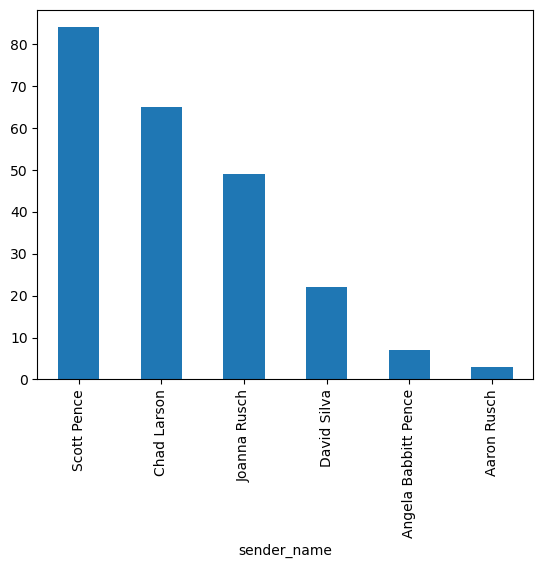

In [23]:
mess_df_tidy_sorted['content'].plot(kind='bar')

Let us try 'area'

<Axes: xlabel='sender_name'>

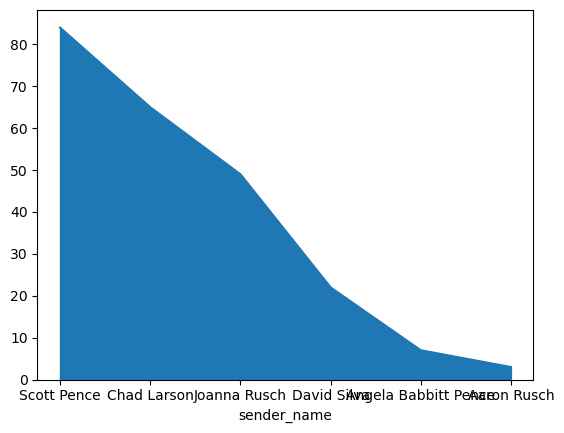

In [25]:
mess_df_tidy_sorted['content'].plot(kind = 'area')